In [1]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
# Step 2: Create Dataset

np.random.seed(42)

n = 500

lead_data = pd.DataFrame({
    'age': np.random.randint(18, 60, n),
    'annual_income': np.random.randint(20000, 150000, n),
    'website_visits': np.random.randint(1, 50, n),
    'pages_viewed': np.random.randint(1, 100, n),
    'time_spent_minutes': np.random.randint(1, 300, n),
    'email_click_rate': np.random.uniform(0, 1, n),
    'previous_purchases': np.random.randint(0, 20, n),
    'ad_clicks': np.random.randint(0, 30, n),
    'customer_score': np.random.randint(1, 100, n)
})

lead_data.head()

,age,annual_income,website_visits,pages_viewed,time_spent_minutes,email_click_rate,previous_purchases,ad_clicks,customer_score
0,56,81476,4,56,242,0.692161,0,18,28
1,46,64811,10,33,2,0.062292,19,16,91
2,32,56208,3,36,225,0.509422,13,5,68
3,25,40150,41,20,289,0.996697,10,15,15
4,38,91180,45,83,233,0.813970,2,23,99


In [5]:
# Step 3: Basic Data Exploration

lead_data.shape

(500, 9)

In [6]:
lead_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 500 non-null    int32  
 1   annual_income       500 non-null    int32  
 2   website_visits      500 non-null    int32  
 3   pages_viewed        500 non-null    int32  
 4   time_spent_minutes  500 non-null    int32  
 5   email_click_rate    500 non-null    float64
 6   previous_purchases  500 non-null    int32  
 7   ad_clicks           500 non-null    int32  
 8   customer_score      500 non-null    int32  
dtypes: float64(1), int32(8)
memory usage: 19.7 KB


In [7]:
lead_data.describe()

,age,annual_income,website_visits,pages_viewed,time_spent_minutes,email_click_rate,previous_purchases,ad_clicks,customer_score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,39.326000,82294.556000,25.056000,50.948000,150.614000,0.507510,9.47600,14.524000,50.464000
std,12.200386,38237.052641,14.255079,29.043698,87.039582,0.287402,5.78172,8.445121,27.538872
min,18.000000,20055.000000,1.000000,1.000000,1.000000,0.003218,0.00000,0.000000,1.000000
25%,29.000000,47667.000000,11.750000,25.000000,81.500000,0.258098,4.00000,8.000000,27.000000
50%,41.000000,77935.500000,26.000000,50.000000,146.500000,0.518243,10.00000,14.000000,52.000000
75%,50.000000,115127.250000,37.000000,77.000000,228.250000,0.760465,14.00000,22.000000,73.000000
max,59.000000,149695.000000,49.000000,99.000000,299.000000,0.998348,19.00000,29.000000,99.000000


In [8]:
lead_data.isnull().sum()

age                   0
annual_income         0
website_visits        0
pages_viewed          0
time_spent_minutes    0
email_click_rate      0
previous_purchases    0
ad_clicks             0
customer_score        0
dtype: int64

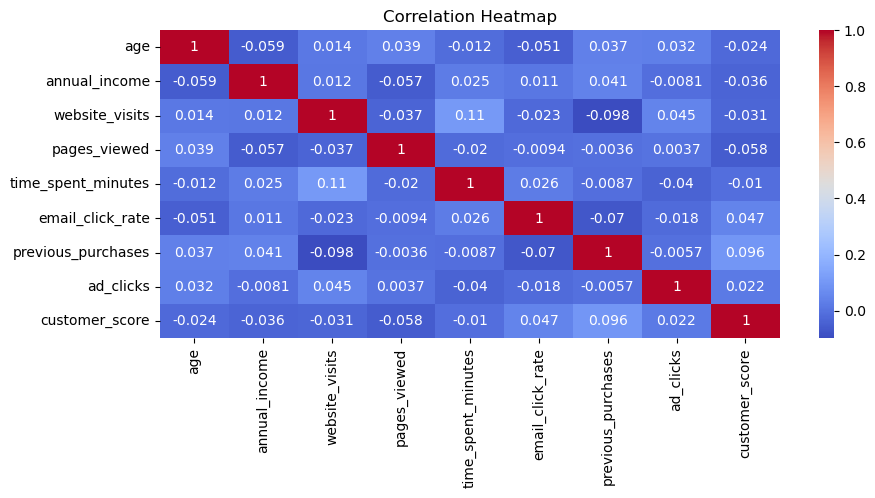

In [10]:
# Step 4: Exploratory Data Analysis (EDA)

# 1. Correlation Heatmap

plt.figure(figsize=(10,4))
sns.heatmap(lead_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

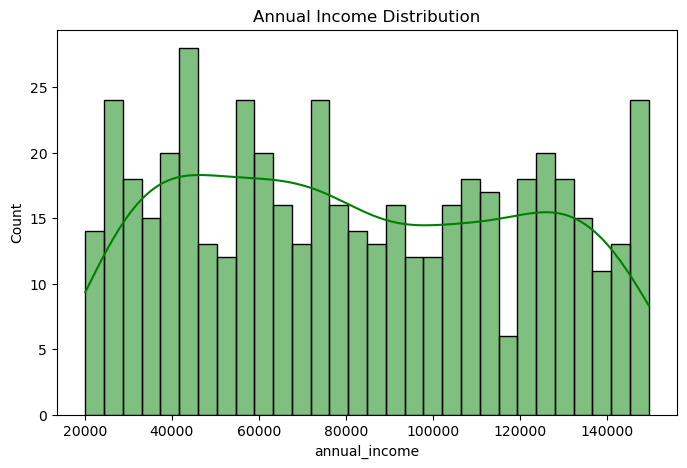

In [11]:
# 2. Annual Income Distribution

plt.figure(figsize=(8,5))
sns.histplot(lead_data['annual_income'], bins=30, kde=True, color='green')
plt.title('Annual Income Distribution')
plt.show()

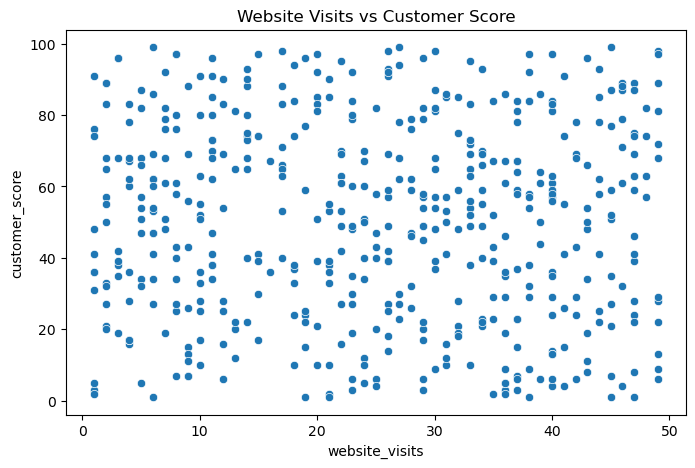

In [12]:
# 3. Website Visits vs Customer Score

plt.figure(figsize=(8,5))
sns.scatterplot(x='website_visits', y='customer_score', data=lead_data)
plt.title('Website Visits vs Customer Score')
plt.show()

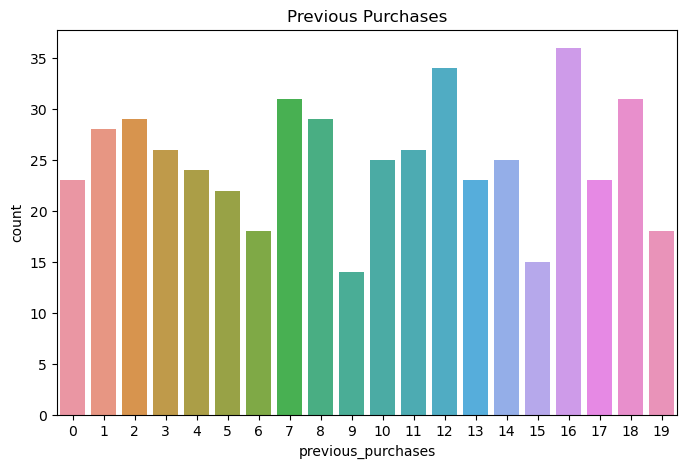

In [13]:
# 4. Previous Purchases Distribution

plt.figure(figsize=(8,5))
sns.countplot(x='previous_purchases', data=lead_data)
plt.title('Previous Purchases')
plt.show()

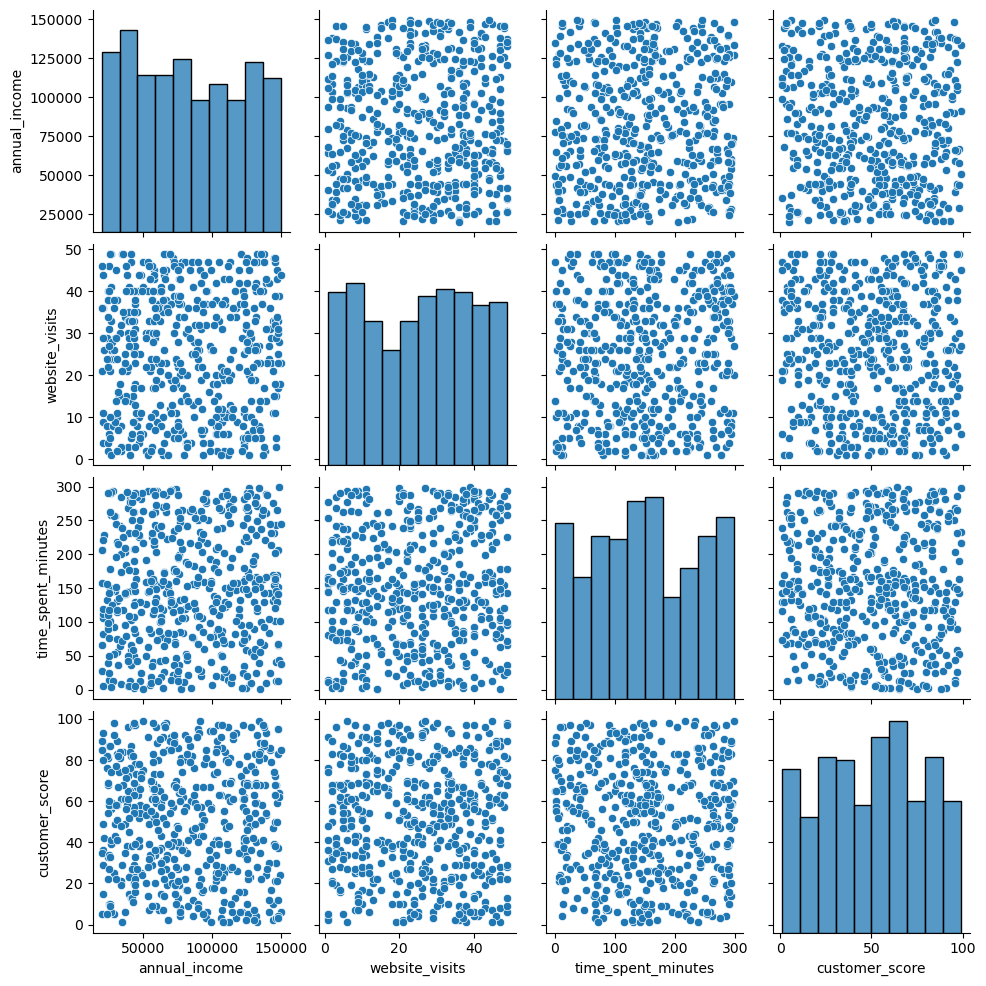

In [14]:
# 5. Pairplot

sns.pairplot(lead_data[['annual_income',
                        'website_visits',
                        'time_spent_minutes',
                        'customer_score']])
plt.show()

In [16]:
# Step 5: Feature Scaling

# K-Means works best when features are scaled.

scaler = StandardScaler()
scaled_data = scaler.fit_transform(lead_data)

In [17]:
# Step 6: Find Optimal Clusters using Elbow Method

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

C:\Users\Mohit Kedia\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Mohit Kedia\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Mohit Kedia\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Mohit Kedia\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it 

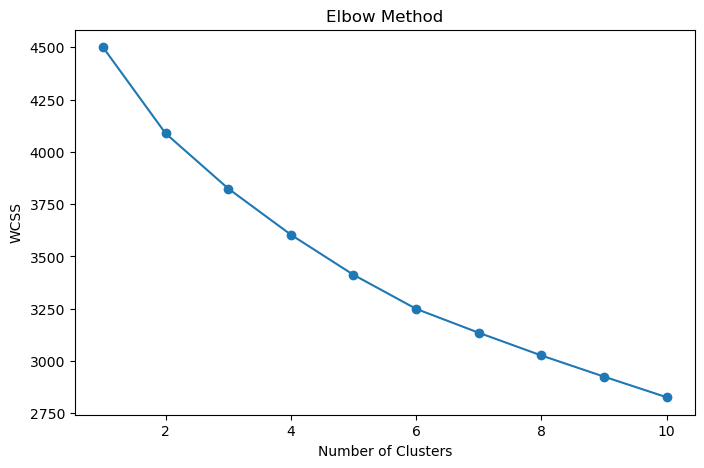

In [18]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [19]:
# Optimal clusters = 3

In [20]:
# Step 7: Train K-Means Model

kmeans = KMeans(n_clusters=3, random_state=42)
lead_data['cluster'] = kmeans.fit_predict(scaled_data)

C:\Users\Mohit Kedia\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Mohit Kedia\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [21]:
# Step 8: Convert Cluster into Lead Type

cluster_summary = lead_data.groupby('cluster')[['annual_income',
                                                 'website_visits',
                                                 'customer_score',
                                                 'previous_purchases']].mean()

print(cluster_summary)

         annual_income  website_visits  customer_score  previous_purchases
cluster                                                                   
0         81469.132184       15.442529       51.568966           11.563218
1         87958.777778       21.843137       54.496732            9.516340
2         78115.352601       37.566474       45.786127            7.341040


In [22]:
lead_mapping = {
    0: 'Cold Lead',
    1: 'Warm Lead',
    2: 'Hot Lead'
}

lead_data['lead_type'] = lead_data['cluster'].map(lead_mapping)

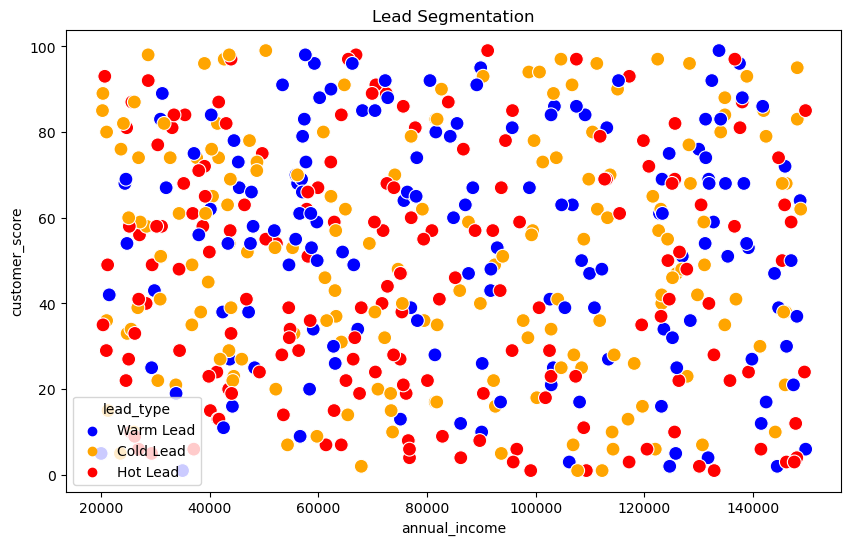

In [23]:
# Step 9: Cluster Visualization

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='annual_income',
    y='customer_score',
    hue='lead_type',
    palette=['blue', 'orange', 'red'],
    data=lead_data,
    s=100
)

plt.title('Lead Segmentation')
plt.show()

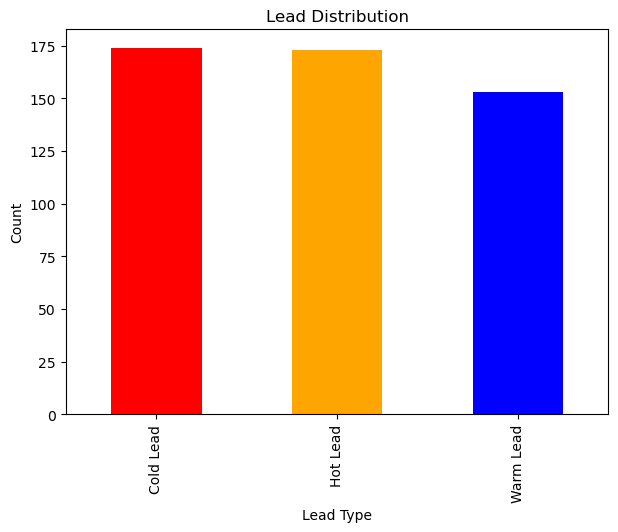

In [24]:
# Step 10: Lead Distribution

plt.figure(figsize=(7,5))
lead_data['lead_type'].value_counts().plot(
    kind='bar',
    color=['red', 'orange', 'blue']
)

plt.title('Lead Distribution')
plt.xlabel('Lead Type')
plt.ylabel('Count')
plt.show()

In [25]:
# Step 11: Silhouette Score

score = silhouette_score(scaled_data, lead_data['cluster'])
print('Silhouette Score:', score)

Silhouette Score: 0.08220599966231425


In [26]:
# A higher silhouette score means better clustering.



In [28]:
# Step 12: Predict Future Lead

#Suppose a new customer has:

#Feature	Value
# age	30
# annual_income	120000
# website_visits	40
# pages_viewed	80
# time_spent_minutes	250
# email_click_rate	0.9
# previous_purchases	15
# ad_clicks	20
# customer_score	95

In [33]:
# Create Future Lead Data

future_lead = pd.DataFrame({
    'age': [30],
    'annual_income': [120000],
    'website_visits': [10],
    'pages_viewed': [10],
    'time_spent_minutes': [50],
    'email_click_rate': [0.4],
    'previous_purchases': [15],
    'ad_clicks': [20],
    'customer_score': [25]
})

In [34]:
# Scale Future Lead

future_scaled = scaler.transform(future_lead)

In [35]:
# Predict Cluster

predicted_cluster = kmeans.predict(future_scaled)
print(predicted_cluster)

[0]


In [36]:
# Convert Cluster to Lead Type

predicted_lead = lead_mapping[predicted_cluster[0]]
print('Predicted Lead Type:', predicted_lead)

Predicted Lead Type: Cold Lead
